In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../../../../../Data/Iris.csv")
df.drop(columns=['Id'])

encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]
df

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1
...,...,...,...
145,3.0,5.2,2
146,2.5,5.0,2
147,3.0,5.2,2
148,3.4,5.4,2


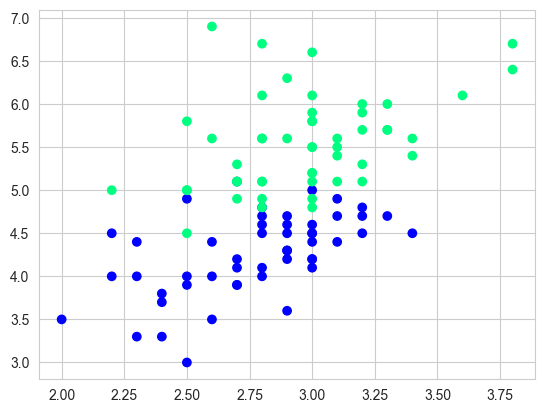

In [3]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')

In [4]:
df = df.sample( df.shape[0] )   # shffle

df_train = df.iloc[:60, :]
df_individual_test = df.iloc[60:80, :].sample(5)
df_voting_test = df.iloc[80:, :].sample(5)

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
def X_y_split(df):
    return df.iloc[:,:-1], df.iloc[:,-1]

In [7]:
X_individual_testing, y_individual_testing = X_y_split(df_individual_test)

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

def evaluateModelTree(model, X_train, y_train):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_individual_testing)
    print("Accuracy Score:", accuracy_score(y_individual_testing, y_pred)) 
    plot_tree(
        model,
        feature_names=X_train.columns,
        class_names=[str(int(cls)) for cls in np.unique(y_train)],
        filled=True,
        rounded=True,
        fontsize=10
    )
    
    
    plt.show()
    plot_decision_regions(X_train.values, y_train.values, clf=model, legend=2)

### Tree 1 

Accuracy Score: 0.8


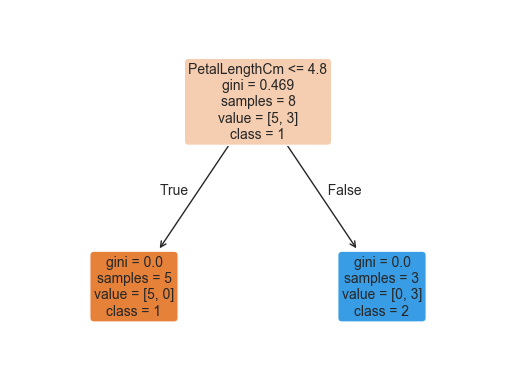

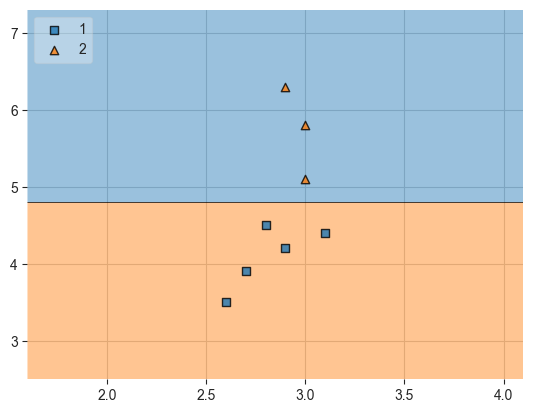

In [15]:
from sklearn.tree import DecisionTreeClassifier

df_train_sample_of_sample1 = df_train.sample(8, replace=False)

X_train1, ytrain1= X_y_split(df_train_sample_of_sample1)

dt1 = DecisionTreeClassifier()
evaluateModelTree(dt1, X_train1, ytrain1)

### Tree2

Accuracy Score: 0.8


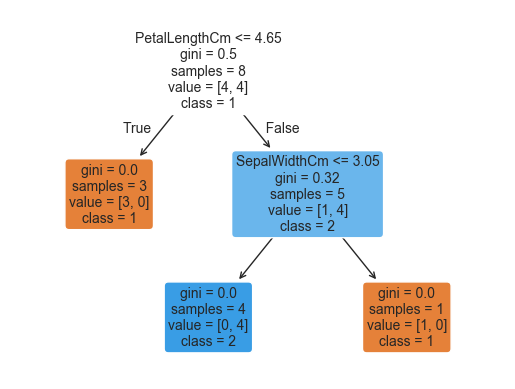

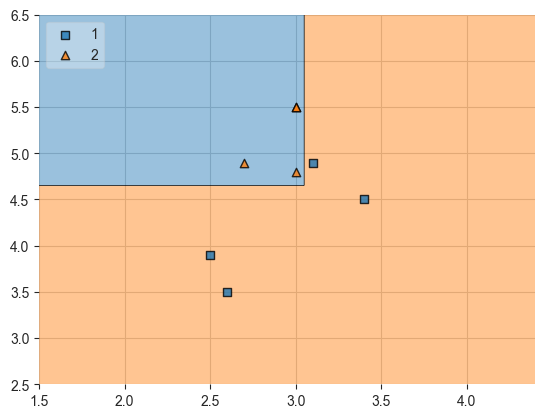

In [16]:
df_train_sample_of_sample2 = df_train.sample(8, replace=False)

X_train2, ytrain2= X_y_split(df_train_sample_of_sample2)

dt2 = DecisionTreeClassifier()
evaluateModelTree(dt2, X_train2, ytrain2)

### Tree3

Accuracy Score: 0.8


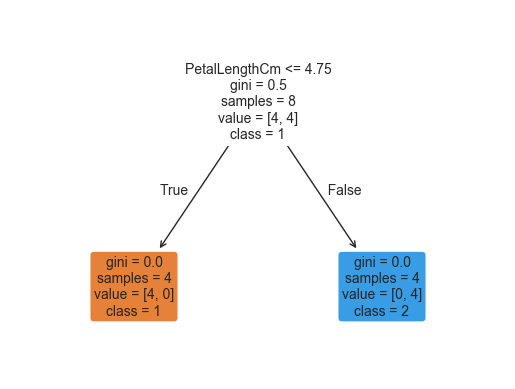

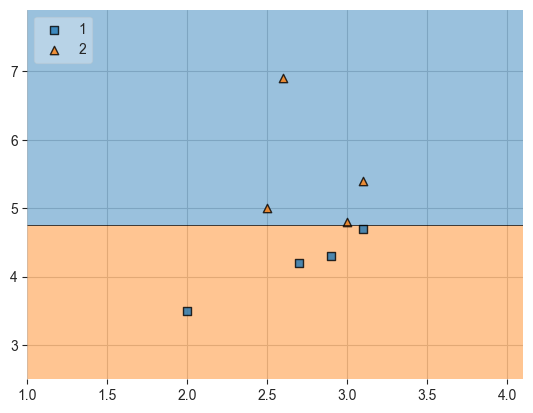

In [17]:
df_train_sample_of_sample3 = df_train.sample(8, replace=False)

X_train3, ytrain3= X_y_split(df_train_sample_of_sample3)

dt3 = DecisionTreeClassifier()
evaluateModelTree(dt3, X_train3, ytrain3)

# Individual model Prediction

In [12]:
df_voting_test

,SepalWidthCm,PetalLengthCm,Species
57,2.4,3.3,1
108,2.5,5.8,2
90,2.6,4.4,1
101,2.7,5.1,2
105,3.0,6.6,2


In [13]:
for data_no in range(df_voting_test.shape[0]):
    print("Data no: ", data_no)
    print("DT1 Prediction: ",dt1.predict(df_voting_test.iloc[data_no,:-1].values.reshape(1,2)))
    print("DT2 Prediction: ",dt2.predict(df_voting_test.iloc[data_no,:-1].values.reshape(1,2)))
    print("DT3 Prediction: ",dt3.predict(df_voting_test.iloc[data_no,:-1].values.reshape(1,2)))
    print("Actual:", df_voting_test.iloc[data_no,-1])
    print("--------------------------------------")

Data no:  0
DT1 Prediction:  [2]
DT2 Prediction:  [1]
DT3 Prediction:  [1]
Actual: 1
--------------------------------------
Data no:  1
DT1 Prediction:  [2]
DT2 Prediction:  [2]
DT3 Prediction:  [2]
Actual: 2
--------------------------------------
Data no:  2
DT1 Prediction:  [2]
DT2 Prediction:  [1]
DT3 Prediction:  [1]
Actual: 1
--------------------------------------
Data no:  3
DT1 Prediction:  [2]
DT2 Prediction:  [2]
DT3 Prediction:  [2]
Actual: 2
--------------------------------------
Data no:  4
DT1 Prediction:  [2]
DT2 Prediction:  [2]
DT3 Prediction:  [2]
Actual: 2
--------------------------------------
